# Dpi Setting

In [2]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100 # 300

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from package_sampling.sampling import up_tille, up_brewer, up_systematic, up_max_entropy
from package_sampling.utils import inclusion_probabilities


In [5]:
import os

print(os.getcwd())

/home/divar/projects/graphical-sampling/Simulations ipynb


In [6]:
import os
os.chdir('/home/divar/projects/graphical-sampling')

### Dependencies

### Python

In [7]:
# !pip install -q git+https://github.com/mehdimhb/geometric-sampling@dev
# !pip install git+https://github.com/mehdimhb/geometric-sampling@legacy-measure

In [8]:
# !apt-get install -y r-base
#!pip install -q rpy2 tqdm


In [9]:
from rpy2.robjects.packages import importr

import numpy as np
from rpy2.robjects import numpy2ri, default_converter, globalenv
from rpy2.robjects.conversion import localconverter

/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "LD_LIBRARY_PATH" redefined by R and overriding existing variable. Current: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server", R: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server"
  warnings.warn(
/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_LIBS_SITE" redefined by R and overriding existing variable. Current: "/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library:/usr/lib/R/site-library:/usr/lib/R/library", R: "/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library:/usr/lib/R/site-library:/usr/lib/R/library:/usr/lib/R/library:/usr/lib/R/

In [10]:
%load_ext rpy2.ipython

### R

In [11]:
%%R

#library(spcosa)
#ibrary(spsurvey)
if(!require(WaveSampling)){
    install.packages("WaveSampling")
    library(WaveSampling)
}
if(!require(sampling)){
    install.packages("sampling")
    library(sampling)
}
if(!require(BalancedSampling)){
    install.packages("BalancedSampling")
    library(BalancedSampling)
}

Loading required package: WaveSampling
Loading required package: Matrix
Loading required package: sampling
Loading required package: BalancedSampling


### Imports

In [12]:
import matplotlib as mpl
import numpy as np
from rpy2.robjects import r, numpy2ri
import rpy2.robjects as ro
from matplotlib import pyplot as plt
from itertools import combinations
from collections import OrderedDict
import pandas as pd
import graphical_sampling as gs
from tqdm import tqdm
from tqdm.contrib import tenumerate
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

#numpy2ri.activate()

rng = gs.random.rng()

/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Functions

### Scores in R

In [13]:
def scores(coords, probs, n, N, sample_idx, split_size, density_measure=None):
    assert len(coords) == len(probs) == N
    assert len(sample_idx) == n
    sample_mask = np.zeros(N, dtype=int)
    sample_mask[sample_idx] = 1

    with localconverter(default_converter + numpy2ri.converter):
      globalenv['sample_mask'] = sample_mask
      globalenv['sample_idx'] = sample_idx + 1  # Or int(sample_idx + 1) if it's just one value
      globalenv['coords'] = coords
      globalenv['probs'] = probs
      globalenv['n'] = n
      globalenv['N'] = N
    # ro.globalenv['sample_mask'] = sample_mask
    # ro.globalenv['sample_idx'] = sample_idx + 1
    # ro.globalenv['coords'] = coords
    # ro.globalenv['probs'] = probs
    # ro.globalenv['n'] = n
    # ro.globalenv['N'] = N
    #ro.globalenv['split_size'] = split_size


    r_code = """
W <- wpik(coords,probs)
W <- W - diag(diag(W))
diag(W) <- 0  # Ensure W has zero diagonal


ib_value <- tryCatch({
  IB(W, sample_mask)  # Moran's Index
}, error = function(e) {
  Inf
})

sb_value <- tryCatch({
  sb(probs, coords, sample_idx)  # Spatial balance
}, error = function(e) {
  Inf
})

sblb_value <- tryCatch({
  sblb(probs, coords, sample_idx)  # Spatial balance using local balance
}, error = function(e) {
  Inf
})
"""
    ro.r(r_code)
    IB_value = ro.r("ib_value")[0]
    SB_value = ro.r("sb_value")[0]
    SBLB_value = ro.r("sblb_value")[0]
    if density_measure is None:
      scaled_coords = (coords - np.min(coords, axis=0)) / np.ptp(coords, axis=0)
      density_measure = gs.measure.Density(scaled_coords, probs, n, split_size=0.001)
    print(sample_idx.reshape(1, -1))
    print(density_measure.score(sample_idx.reshape(1, -1)))
    scores, _ = density_measure.score(sample_idx.reshape(1, -1))
    return scores[0][0], IB_value, SBLB_value
    # return scores[0][0], SB_value, IB_value, SBLB_value
    # Legacy Measure: return scores[3][0], SB_value, IB_value, SBLB_value

### Functions

In [14]:
autumn_cmap = plt.get_cmap('autumn')
plasma_cmap = plt.get_cmap('plasma')

def get_autumn_colors(n_clusters):
    """Returns n_clusters colors from the autumn colormap."""
    colors = autumn_cmap(np.linspace(0.15, 0.95, n_clusters))
    return colors

def get_plasma_colors(n_clusters):
    """Returns n_clusters colors from the plasma colormap."""
    colors = plasma_cmap(np.linspace(0.15, 0.95, n_clusters))
    return colors

# Example usage:
n = 10  # Number of clusters
n_clusters = n
import matplotlib.pyplot as plt
import numpy as np

def lighten_color(color, amount=0.5):
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = np.array(mc.to_rgb(c))
    white = np.array([1, 1, 1])
    return tuple((1 - amount) * c + amount * white)

n_clusters = n
base_colors = plt.cm.plasma(np.linspace(0, 1, n_clusters))
light_colors = [lighten_color(col, 0.5) for col in base_colors]

autumn_colors = get_autumn_colors(n_clusters)
plasma_colors = get_plasma_colors(n_clusters)
plasma_colors = light_colors

In [15]:
def plot_convex_hull(points, ax, color, alpha=0.33, edge_color="gray", line_width=0.6):
    """Plot convex hull safely. Always returns (ax, hull or None)."""
    if len(points) < 3:
        return ax, None
    try:
        hull = ConvexHull(points)
        polygon = Polygon(
            points[hull.vertices],
            closed=True,
            facecolor=color,
            alpha=alpha,
            edgecolor=edge_color,
            lw=line_width,
            zorder=1
        )
        ax.add_patch(polygon)
        return ax, hull
    except QhullError:
        # Can't make hull, skip
        return ax, None


# Simulations

### Methods

In [16]:
import numpy as np
import rpy2.robjects as ro
from rpy2.robjects import default_converter, numpy2ri
from rpy2.robjects.conversion import localconverter

def local_pivotal_samples(coords, probs, n, num_samples):
    samples_idx = np.zeros((num_samples, n), dtype=int)
    for i in range(num_samples):
        with localconverter(default_converter + numpy2ri.converter):
            ro.globalenv['coords'] = coords
            ro.globalenv['probs'] = probs
        r_code = """
s <- lpm(probs, coords) # Local Pivotal Method (BalancedSampling)
"""
        ro.r(r_code)
        with localconverter(default_converter + numpy2ri.converter):
            sample_idx = np.array(list(ro.r("s"))) - 1
        samples_idx[i] = sample_idx

    return samples_idx

def k_means_samples(coords, probs, n, num_samples, n_zones, sort_method):
    # Placeholder, replace with your actual method if necessary
    return gs.sampling.KMeansSpatialSamplingSimple(coords, probs, n=n, n_zones=n_zones, sort_method=sort_method, tolerance=2, split_size=0.001).sample(num_samples)

def random_samples(coords, probs, n, num_samples):
    # Placeholder, replace with your implementation if available
    return gs.sampling.RandomSampling(coords, probs, n=n).sample(num_samples)

def upmaxentropy_samples(probs, num_samples):
    with localconverter(default_converter + numpy2ri.converter):
        ro.globalenv['probs'] = probs
    n = int(round(np.sum(probs)))

    samples_idx = np.zeros((num_samples, n), dtype=int)
    for i in range(num_samples):
        r_code = """
mask <- UPmaxentropy(probs)
"""
        ro.r(r_code)
        with localconverter(default_converter + numpy2ri.converter):
            mask = np.array(ro.r("mask"))
        if mask.dtype != np.bool_:
            mask = mask.astype(bool)
        sample_idx = np.where(mask)[0]
        samples_idx[i] = sample_idx

    return samples_idx

def wave_samples(coords, probs, n, num_samples):
    with localconverter(default_converter + numpy2ri.converter):
        ro.globalenv['coords'] = coords
        ro.globalenv['probs'] = probs

    samples_idx = np.zeros((num_samples, n), dtype=int)
    for i in range(num_samples):
        r_code = """
wave_mask <- wave(coords, probs)
"""
        ro.r(r_code)
        with localconverter(default_converter + numpy2ri.converter):
            mask = np.array(ro.r("wave_mask"))
        if mask.dtype != np.bool_:
            mask = mask.astype(bool)
        sample_idx = np.where(mask)[0]
        samples_idx[i] = sample_idx

    return samples_idx

def spcosa_samples(coords, n, num_samples):
    """
    Uses the spcosa R package for equal probability spatially balanced sampling.
    """
    with localconverter(default_converter + numpy2ri.converter):
        ro.globalenv['coords'] = coords
    N = coords.shape[0]
    samples_idx = np.zeros((num_samples, n), dtype=int)
    for i in range(num_samples):
        r_code = f"""
library(spcosa)
set.seed({np.random.randint(1, 1e8)})
df <- data.frame(x = coords[,1], y = coords[,2])
coordinates(df) <- ~x + y
gridded(df) <- TRUE
stratification <- stratify(df, nStrata = {n}, nTry = 50)
samples <- spsample(stratification)
# Extract row indices in original data
whichrow <- as.integer(rownames(as(samples, "data.frame")))
"""
        ro.r(r_code)
        with localconverter(default_converter + numpy2ri.converter):
            sample_idx = np.array(ro.r("whichrow")) - 1  # zero-based for Python
        samples_idx[i] = sample_idx
    return samples_idx

def find_samples(coords, probs, n, num_samples, ep_mode="auto"):
    """
    Returns a dict of various sampling methods. 
    If ep_mode=="auto", heuristically deduce EP/UP from probs.
    """
    # Determine if this is the EP case: uniform probs and sum ~ n
    result = {
        "K-Means (11_lexico)": k_means_samples(coords, probs, n, num_samples, (1, 1), sort_method="lexico"),
        "K-Means (11_random)": k_means_samples(coords, probs, n, num_samples, (1, 1), sort_method="random"),
        # "K-Means (12_lexico)": k_means_samples(coords, probs, n, num_samples, (1, 2), sort_method="lexico"),
        # "K-Means (12_random)": k_means_samples(coords, probs, n, num_samples, (1, 2), sort_method="random"),
        # "K-Means (22_lexico)": k_means_samples(coords, probs, n, num_samples, (2, 2), sort_method="lexico"),
        # "K-Means (22_random)": k_means_samples(coords, probs, n, num_samples, (2, 2), sort_method="random"),
        # "K-Means (23_lexico)": k_means_samples(coords, probs, n, num_samples, (2, 3), sort_method="lexico"),
        # "K-Means (23_random)": k_means_samples(coords, probs, n, num_samples, (2, 3), sort_method="random"),
        "Local Pivotal": local_pivotal_samples(coords, probs, n, num_samples),
        "Random": random_samples(coords, probs, n, num_samples),
        "UPmaxentropy": upmaxentropy_samples(probs, num_samples),
        "Wave": wave_samples(coords, probs, n, num_samples),
    }
    return result

### river plot

In [17]:
%%R
library(sf)
library(sp)

# load meuse river data
data(meuse.riv)

# convert to sf object
meuse_sf <- st_sfc(st_linestring(meuse.riv), crs = 28992)

# save as shapefile
st_write(meuse_sf, "meuse_river.shp", delete_layer=TRUE)


Deleting layer `meuse_river' using driver `ESRI Shapefile'
Writing layer `meuse_river' to data source 
  `meuse_river.shp' using driver `ESRI Shapefile'
Writing 1 features with 0 fields and geometry type Line String.


Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.4.0; sf_use_s2() is TRUE


In [18]:
import numpy as np
import pandas as pd

# --- SEEDING for reproducibility ---
np.random.seed(42)

# --- PARAMS ---
n = 4  # Target sample size
meuse_csv = '/home/divar/projects/graphical-sampling/meuse.csv'

# --- 1) Load MEUSE and make probabilities ---
meuse_df = pd.read_csv(meuse_csv)
coords_meuse = meuse_df[['x', 'y']].to_numpy()
N_meuse = coords_meuse.shape[0]
area = meuse_df['copper'].clip(1, 150)

# Assumes you have these in scope:
#   rng.equal_probabilities(n, N)
#   inclusion_probabilities(area, n)
probs_meuse_eq   = rng.equal_probabilities(n, N_meuse)
probs_meuse_uneq = inclusion_probabilities(area, n)

# --- 2) Build Population objects (so we keep coords & probs together) ---
pop_eq = gs.sampling.Population(coords=coords_meuse, probs=probs_meuse_eq)
pop_uneq = gs.sampling.Population(coords=coords_meuse, probs=probs_meuse_uneq)

# --- 3) Sampler params ---
units_order = 'spiral'
zones_order = 'spiral'
zone_builder = 'sweep'
n_zones = (2, 2)

# --- 4) Build samplers (KEEP REFERENCES!) ---
hard_eq = gs.sampling.KMeansSampler(
    population=pop_eq,
    n=n,
    n_zones=n_zones,
    zone_builder=zone_builder,
    units_order=units_order,
    zones_order=zones_order,
    split_size=0.1
)

hard_uneq = gs.sampling.KMeansSampler(
    population=pop_uneq,
    n=n,
    n_zones=n_zones,
    zone_builder=zone_builder,
    units_order=units_order,
    zones_order=zones_order,
    split_size=0.1
)

# If your implementation requires it, uncomment:
# hard_eq.build(); hard_uneq.build()

# --- 5) (Optional) keep populations in a dict if you like that pattern ---
pop_objs = {
    'meuse_eq':   hard_eq.population,   # Population object
    'meuse_uneq': hard_uneq.population, # Population object
}

# IMPORTANT: do NOT overwrite hard_eq / hard_uneq with populations.
# Leave them pointing to the sampler objects, e.g.:
# hard_eq is the sampler for equal-prob; hard_uneq is the sampler for unequal-prob.


/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "LD_LIBRARY_PATH" redefined by R and overriding existing variable. Current: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server", R: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server"
  warnings.warn(
/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_LIBS_SITE" redefined by R and overriding existing variable. Current: "/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library:/usr/lib/R/site-library:/us

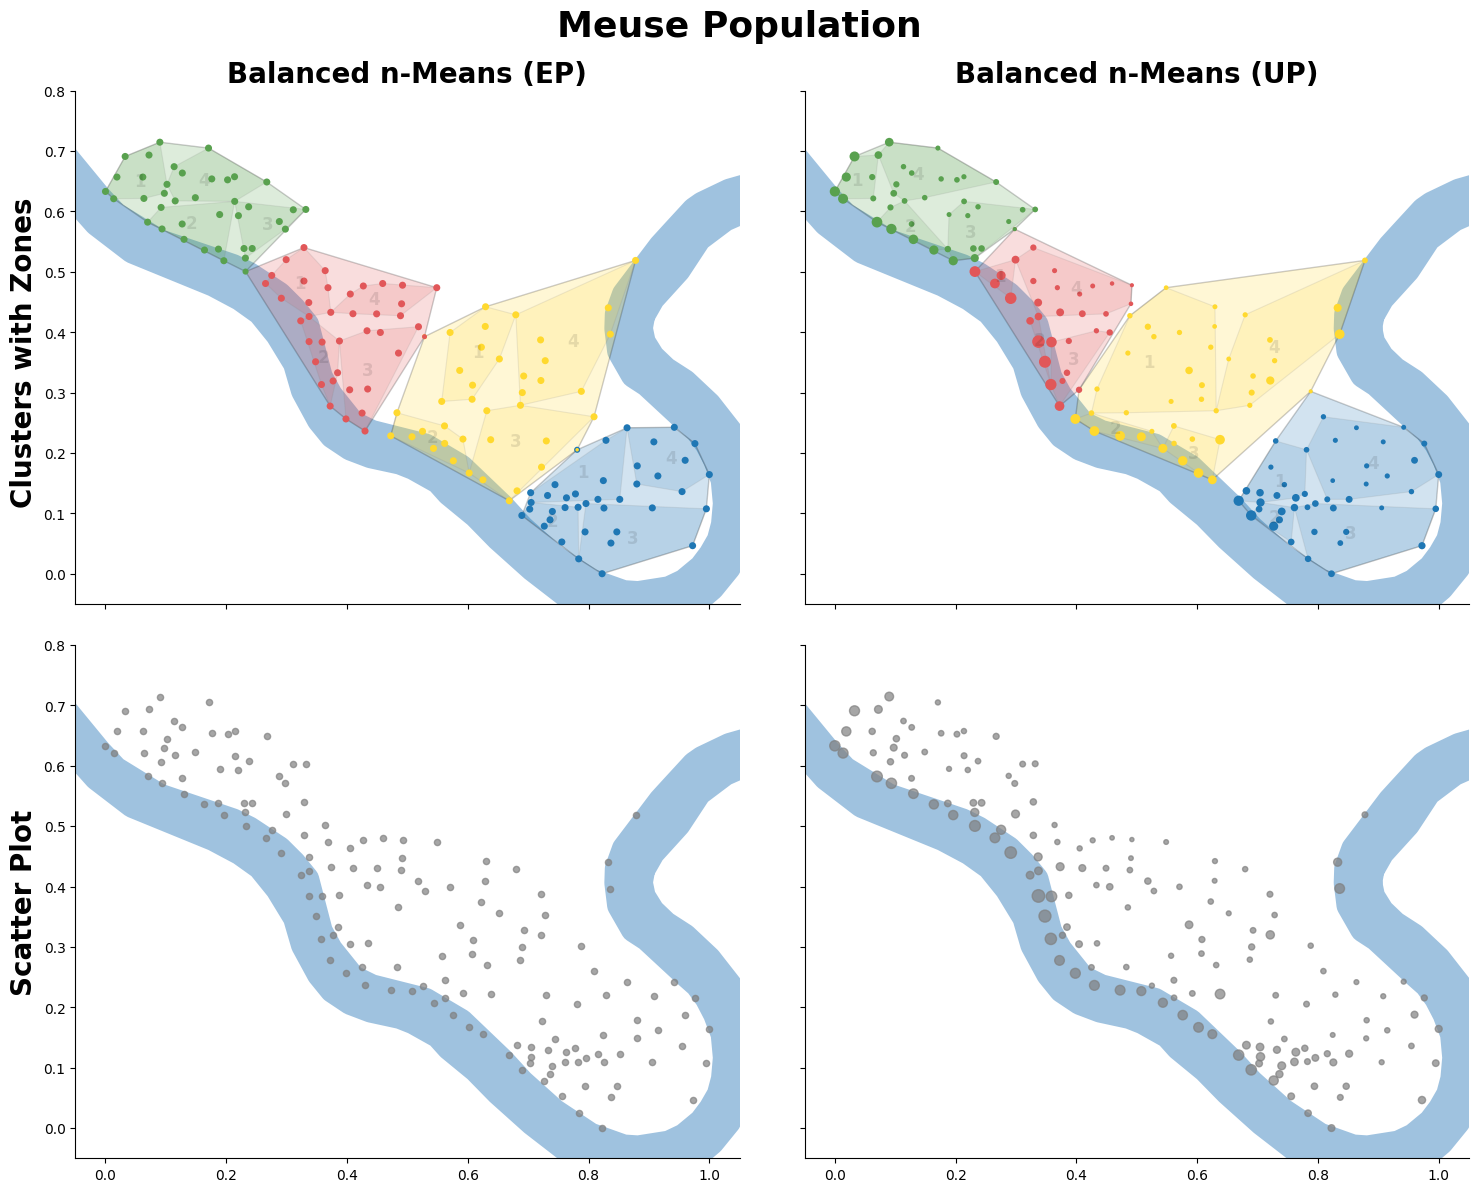

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.affinity import translate, scale, rotate

# --- River -> normalize to unit space like Population, then rotate 90° left ---
river = gpd.read_file("/home/divar/projects/graphical-sampling/meuse_river.shp").to_crs(epsg=28992)

XY    = meuse_df[['x','y']].to_numpy(float)
mins  = XY.min(axis=0)
span  = np.ptp(XY, axis=0)
scale_val = float(span.max())

river_unit = river.copy()
if scale_val > 0:
    river_unit["geometry"] = river_unit.geometry.apply(
        lambda g: scale(translate(g, xoff=-mins[0], yoff=-mins[1]),
                        xfact=1.0/scale_val, yfact=1.0/scale_val, origin=(0, 0))
    )

# rotate left 90° around (0,0); shift +1 in x to keep it in [0,1]
river_rot = river_unit.copy()
river_rot["geometry"] = river_rot.geometry.apply(
    lambda g: translate(rotate(g, 90, origin=(0, 0)), xoff=1.0, yoff=0.0)
)

# rotate points in unit space: x' = 1 - y, y' = x
def rot_left_unit(coords):
    return np.column_stack([1.0 - coords[:, 1], coords[:, 0]])

# rotated populations just for plotting (clusters still refer to indices)
pop_eq_rot   = gs.sampling.Population(coords=rot_left_unit(pop_eq.coords),   probs=pop_eq.probs,   ids=pop_eq.ids)
pop_uneq_rot = gs.sampling.Population(coords=rot_left_unit(pop_uneq.coords), probs=pop_uneq.probs, ids=pop_uneq.ids)

# --- Labels and figure, styled like your Switzerland code ---
col_labels = ["EP-Balanced n-Means", "UP-Balanced n-Means"]

fig, axes = plt.subplots(2, 2, figsize=(15, 12), sharex=True, sharey=True)

for col, (pops, hard, key) in enumerate([(pop_eq_rot, hard_eq, 'meuse_eq'),
                                         (pop_uneq_rot, hard_uneq, 'meuse_uneq')]):

    # ----------- BOTTOM ROW: scatter over river -----------
    ax = axes[1, col]
    # river as background (linework); use river-blue color and thin stroke
    river_rot.plot(ax=ax, color="#87b3d8", linewidth=20, alpha=0.8, zorder=0)
    coords = pops.coords
    probs  = pops.probs

    if key == 'meuse_eq':
        s = 20                                   # uniform size (like Swiss)
        ax.scatter(coords[:, 0], coords[:, 1], c="gray", s=s, alpha=0.7, zorder=2)
    else:
        s = probs * 1000                        # prob-scaled (like Swiss)
        ax.scatter(coords[:, 0], coords[:, 1], c="gray", s=s, alpha=0.7, zorder=2)

    # ----------- TOP ROW: clusters/hulls over river -----------
    ax = axes[0, col]
    river_rot.plot(ax=ax, color="#87b3d8", linewidth=20, alpha=0.8, zorder=0)
    gs.plot(pops, hard.clusters, ax=ax)         # same spirit as pops.plot(ax=ax) in Swiss
    ax.set_title(col_labels[col], fontsize=20, fontweight='bold')
    ax.set_aspect("equal")

# Only show left and bottom spines (like Swiss)
for ax in axes.flatten():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel("")
    ax.set_ylabel("")

# row labels
axes[0, 0].set_ylabel("Clusters with Zones ", fontsize=20, fontweight='bold')
axes[1, 0].set_ylabel("Scatter Plot", fontsize=20, fontweight='bold')

# Common limits in rotated unit space
for ax in axes.flatten():
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 0.80)

# Spacing & title (match Swiss style)
plt.tight_layout(rect=[0, 0.01, 1, 0.96])
plt.subplots_adjust(wspace=0.08, hspace=0.08)
plt.suptitle("Meuse Population", fontsize=26, fontweight='bold', y=0.995)
plt.show()
